### Yesterday, we processed images on FIJI, did some measurements and saved those into tables as CSV files. 
### Today, we will use Python to read, process and visualise statistics from those tables.

Import the required packages for this activity

In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib import pyplot as plt

In [ ]:
# Define the directory where the csv files from FIJI are located
data_dir = "data"

We can use PIL to load our image into a numpy array and display it

In [ ]:
img = Image.open(f"{data_dir}/RGB_rounding_assay0000.tif")
img = np.array(img)

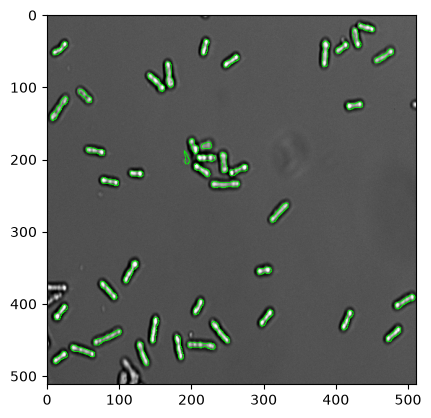

In [ ]:
plt.imshow(img)

Now we will use Pandas to read the csv files we generated previously on FIJI. We will start with a single example.

In [ ]:
data_dir = "data"
csv_file = f"{data_dir}/Results_rounding_assay0000.csv"

df = pd.read_csv(csv_file)

In [ ]:
df

,,Area,XM,YM,Circ.,AR,Round,Solidity
0,1,145,442.976,17.536,0.618,3.103,0.322,0.879
1,2,169,428.704,31.967,0.505,3.814,0.262,0.820
2,3,138,218.961,44.580,0.607,3.105,0.322,0.836
3,4,236,385.571,52.933,0.432,4.953,0.202,0.827
4,5,152,18.510,46.664,0.548,3.525,0.284,0.804
5,6,138,409.022,45.391,0.651,2.690,0.372,0.807
6,7,189,467.364,56.804,0.476,4.452,0.225,0.791
7,8,158,255.432,63.709,0.570,3.478,0.287,0.812
8,9,236,169.472,82.990,0.438,4.925,0.203,0.808
9,10,202,151.772,92.809,0.490,4.257,0.235,0.781


Let's retrieve a sub-dataframe with the areas of all the segmented objects. This involves calling the "Area" column of our dataframe via `df["Area"]`

In [ ]:
areas = df["Area"]
areas

0     145
1     169
2     138
3     236
4     152
5     138
6     189
7     158
8     236
9     202
10    143
11    237
12    151
13    138
14    104
15    168
16     66
17    188
18    181
19    171
20    176
21    123
22    160
23    264
24    216
25    215
26    142
27    193
28    209
29    149
30    162
31    168
32    180
33    216
34    227
35    170
36    256
37    208
38    212
39    246
40    227
41    149
Name: Area, dtype: int64

You can also retrieve a desired value for a specific row. Let us display the area of the 10th cell.

In [ ]:
df.loc[0, "Area"]

We can obtain details such as the number of objects, as well as statistics about the areas, such as the mean, standard deviation and median.

In [ ]:
# len(df) will tell us the number of rows in the dataframe, which is the number of cells detected in this image.
len(df)

42

In [ ]:
mean_area = areas.mean()
print(f"Mean area: {mean_area:.2f}")

Mean area: 180.43


Like with the mean, calculate and print (with f-strings) the standard deviation and the median area. The relevant commands are `.std()` and `.median()`

In [ ]:
# Your code here

Standard deviation of area: 42.80


We can learn about the distribution of area values by plotting a histogram. This will show us the frequencies at which ranges of areas occur in our data.

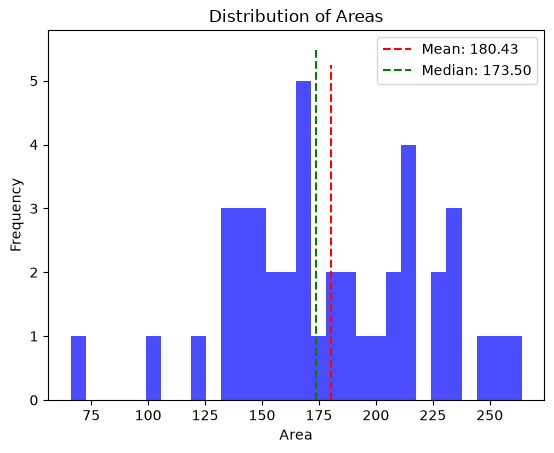

In [ ]:
# Plots a histogram
plt.hist(df["Area"], bins=30, color='blue', alpha=0.7)
# Plot a vertical line for the median
plt.vlines(mean_area, ymin=0, ymax=plt.gca().get_ylim()[1], color='green', linestyle='dashed', label=f'Median: {median_area:.2f}')
# Define the x and y labels and the title of the plot
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.title("Distribution of Areas")
# Display the plot with a legend
plt.legend()
plt.show()

Make a plot of the histogram, with narrower bins, and with lines depicting the mean area +/- the standard deviation. You may use the above code

In [1]:
# Your code here

We can also make scatter plots if we are interested in visually seeing whether some pair of parameter may be correlated. Try it out!

Text(0, 0.5, 'Roundness')

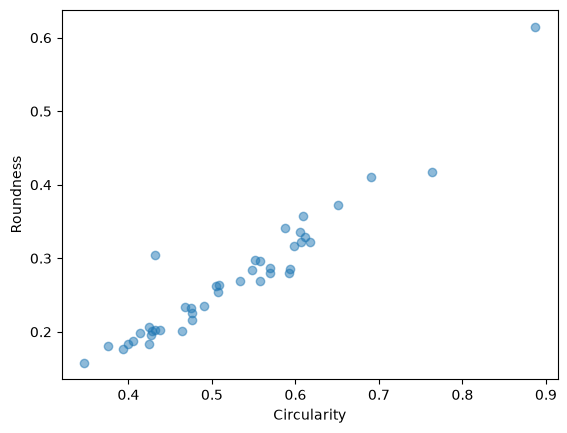

In [ ]:
# TO DO: enter your parameters of interest as two strings. These must match the desired column names in the dataframe. Enter these in the following 2 lines
param_1 = "Circ."
param_2 = "Round"

plt.scatter(df[param_1], df[param_2], marker='o', color='blue', alpha=0.5)
plt.xlabel(param_1)
plt.ylabel(param_2)

# TO DO: on the same plot, add a point representing the means of your two chosen parameters. Use a different color and marker style to distinguish this point from the other data points.
# Include a legend to indicate what this point represents. You can use the label parameter in plt.scatter() to specify the legend entry for this point. 
# Some marker styles you can use are 'o', 's', '^', 'D', '*', etc. You can also specify the size of the marker using the s parameter in plt.scatter().
# You can use plt.scatter() again for this, but make sure to specify the mean values of your chosen parameters as the x and y coordinates of this point.
# Enter your code above plt.xlabel()

Now that we have a dataframe open here, we can also add columns if we like.

In [ ]:
df["Time"] = 0
df

,,Area,XM,YM,Circ.,AR,Round,Solidity,Time
0,1,145,442.976,17.536,0.618,3.103,0.322,0.879,0
1,2,169,428.704,31.967,0.505,3.814,0.262,0.820,0
2,3,138,218.961,44.580,0.607,3.105,0.322,0.836,0
3,4,236,385.571,52.933,0.432,4.953,0.202,0.827,0
4,5,152,18.510,46.664,0.548,3.525,0.284,0.804,0
5,6,138,409.022,45.391,0.651,2.690,0.372,0.807,0
6,7,189,467.364,56.804,0.476,4.452,0.225,0.791,0
7,8,158,255.432,63.709,0.570,3.478,0.287,0.812,0
8,9,236,169.472,82.990,0.438,4.925,0.203,0.808,0
9,10,202,151.772,92.809,0.490,4.257,0.235,0.781,0


This overwrites our df variable, but the csv is unchanged. We can save this updated df as a new csv file (or overwrite our original one)

In [ ]:
csv_save_file = "results_updated_0000.csv"

df.to_csv(f"{data_dir}/{csv_save_file}", index=False)

Notice that we applied the same value to every single row of the dataframe. We can also assign values to individual rows.

In [ ]:
df.loc[0, "Time"] = 7
df

,,Area,XM,YM,Circ.,AR,Round,Solidity,Time
0,1,145,442.976,17.536,0.618,3.103,0.322,0.879,7
1,2,169,428.704,31.967,0.505,3.814,0.262,0.820,0
2,3,138,218.961,44.580,0.607,3.105,0.322,0.836,0
3,4,236,385.571,52.933,0.432,4.953,0.202,0.827,0
4,5,152,18.510,46.664,0.548,3.525,0.284,0.804,0
5,6,138,409.022,45.391,0.651,2.690,0.372,0.807,0
6,7,189,467.364,56.804,0.476,4.452,0.225,0.791,0
7,8,158,255.432,63.709,0.570,3.478,0.287,0.812,0
8,9,236,169.472,82.990,0.438,4.925,0.203,0.808,0
9,10,202,151.772,92.809,0.490,4.257,0.235,0.781,0


We can also iterate with a for loop, check each row for some condition, and then write whether or not it is true in a new column.

As an example, let us make a new column which stores whether or not an object (a row) has an area greater than 150

In [ ]:
# iterate through the rows
for index, row in df.iterrows():
    # Check if the area is greater than 100
    if row["Area"] > 150:
        df.at[index, "Area condition"] = True
    else:
        df.at[index, "Area condition"] = False

df

,,Area,XM,YM,Circ.,AR,Round,Solidity,Time,Area condition
0,1,145,442.976,17.536,0.618,3.103,0.322,0.879,7,False
1,2,169,428.704,31.967,0.505,3.814,0.262,0.820,0,True
2,3,138,218.961,44.580,0.607,3.105,0.322,0.836,0,False
3,4,236,385.571,52.933,0.432,4.953,0.202,0.827,0,True
4,5,152,18.510,46.664,0.548,3.525,0.284,0.804,0,True
5,6,138,409.022,45.391,0.651,2.690,0.372,0.807,0,False
6,7,189,467.364,56.804,0.476,4.452,0.225,0.791,0,True
7,8,158,255.432,63.709,0.570,3.478,0.287,0.812,0,True
8,9,236,169.472,82.990,0.438,4.925,0.203,0.808,0,True
9,10,202,151.772,92.809,0.490,4.257,0.235,0.781,0,True


There is a simpler way through which we could do the same thing as above but with a single line of code

In [ ]:
# first, let's delete the column we just created, so we can start fresh
df = df.drop(columns=["Area condition"])

# Recreate the column based on the condition
df["Area condition"] = df["Area"] > 150
df

,,Area,XM,YM,Circ.,AR,Round,Solidity,Time,Area condition
0,1,145,442.976,17.536,0.618,3.103,0.322,0.879,7,False
1,2,169,428.704,31.967,0.505,3.814,0.262,0.820,0,True
2,3,138,218.961,44.580,0.607,3.105,0.322,0.836,0,False
3,4,236,385.571,52.933,0.432,4.953,0.202,0.827,0,True
4,5,152,18.510,46.664,0.548,3.525,0.284,0.804,0,True
5,6,138,409.022,45.391,0.651,2.690,0.372,0.807,0,False
6,7,189,467.364,56.804,0.476,4.452,0.225,0.791,0,True
7,8,158,255.432,63.709,0.570,3.478,0.287,0.812,0,True
8,9,236,169.472,82.990,0.438,4.925,0.203,0.808,0,True
9,10,202,151.772,92.809,0.490,4.257,0.235,0.781,0,True


In [ ]:
# Count the number of cells that fulfil the condition. Use the .sum() function.

31

In [ ]:
# You can do the same thing directly, without creating a new column

np.int64(31)

We can slice, or select, only the rows which fulfil a condition

In [ ]:
df_large = df[df["Area"] > 150]
df_large

Select the cells which are sufficiently circular, then find the mean area of them.

In [ ]:
# Your code here

Building on this, also select cells that are not circular. Then, make a scatter plot with Circularity as the x-axis and Area as the y-axis.
Indicate the cell category (circular or not) with different marker colours, and include a legend.

In [ ]:
# Your code here

You can also do arithmetic between columns. For example, let's create a new column that is the product of the "Circ." and "Round" columns.

In [ ]:
df["C*R"] = df["Circ."] * df["Round"]
df

,,Area,XM,YM,Circ.,AR,Round,Solidity,Time,Area condition,C*R
0,1,145,442.976,17.536,0.618,3.103,0.322,0.879,7,False,0.198996
1,2,169,428.704,31.967,0.505,3.814,0.262,0.820,0,True,0.132310
2,3,138,218.961,44.580,0.607,3.105,0.322,0.836,0,False,0.195454
3,4,236,385.571,52.933,0.432,4.953,0.202,0.827,0,True,0.087264
4,5,152,18.510,46.664,0.548,3.525,0.284,0.804,0,True,0.155632
5,6,138,409.022,45.391,0.651,2.690,0.372,0.807,0,False,0.242172
6,7,189,467.364,56.804,0.476,4.452,0.225,0.791,0,True,0.107100
7,8,158,255.432,63.709,0.570,3.478,0.287,0.812,0,True,0.163590
8,9,236,169.472,82.990,0.438,4.925,0.203,0.808,0,True,0.088914
9,10,202,151.772,92.809,0.490,4.257,0.235,0.781,0,True,0.115150


Now, let us concatenate another dataframe to this one. That is to say, combine two dataframes into one. We can do this using the `concat()` function. Notice that the argument to `concat()` is a list of the dataframes we wish to combine

In [ ]:
# Let's read another csv file and see if we can combine the dataframes.
df_2 = pd.read_csv(f"{data_dir}/Results_rounding_assay0001.csv")
df_combined = pd.concat([df, df_2], ignore_index=True)

In [ ]:
df_combined

,,Area,XM,YM,Circ.,AR,Round,Solidity,Time,Area condition,C*R
0,1,145,442.976,17.536,0.618,3.103,0.322,0.879,7.0,False,0.198996
1,2,169,428.704,31.967,0.505,3.814,0.262,0.820,0.0,True,0.132310
2,3,138,218.961,44.580,0.607,3.105,0.322,0.836,0.0,False,0.195454
3,4,236,385.571,52.933,0.432,4.953,0.202,0.827,0.0,True,0.087264
4,5,152,18.510,46.664,0.548,3.525,0.284,0.804,0.0,True,0.155632
...,...,...,...,...,...,...,...,...,...,...,...
79,38,235,194.060,457.649,0.368,5.550,0.180,0.741,NaN,NaN,NaN
80,39,213,134.599,469.921,0.397,5.387,0.186,0.753,NaN,NaN,NaN
81,40,221,41.440,466.801,0.393,5.136,0.195,0.752,NaN,NaN,NaN
82,41,99,266.586,476.869,0.871,1.665,0.601,0.917,NaN,NaN,NaN


Notice that there are `NaN` values in the new dataframe for the columns Time, Area condition and C*R. This is because we did not create that column for `df_2`. So, the time column values corresponding to its rows were set to "Not a Number" 

## Processing multiple CSV files and getting information based on the time point

We will apply the principles we have learned today to visualise how some parameters varied with time points.

In [ ]:
# Delete the dataframes we no longer need to free up memory
del df, df_2, df_combined

We have 64 csv files that we generated from the 64 images in FIJI. Let us iterate through all of them and find the number of cells detected in each image.

In [ ]:
# Define the directory where the csv files from FIJI are located
data_dir = "data"

In [ ]:
# we will put the dataframes read from all csv files into a list, and then combine them at the end.
all_dfs = [] # initialize an empty list to hold the dataframes
cell_numbers = [] # initialize an empty list to hold the number of cells in each image

for i in range(64):
    file_number = str(i).zfill(4) # this adds trailing zeros to the number so that it is 4 digits long, e.g. 0000, 0001, 0002, ..., 0063

    # Your code here
    # read the csv file into a dataframe using pd.read_csv() and an f-string to construct the file directory

    # Append the current dataframe to the list of all dataframes

    # Find the number of cells in this csv file and append it to the list of cell numbers


# Combine all the dataframes in the list into a single dataframe

In [ ]:
# Combine all the dfs in the list into a single dataframe
df_combined = pd.concat(all_dfs, ignore_index=True)

Let's plot the cell count over time. Use the `plt.plot()` function to plot the x and y values. Make sure to label your axes and include a title.

In [2]:
# Your code here

**Task**: From the combined dataframe, try to find the number of cells that are round at each time point. We'll consider a cell round if its circularity (Circ.) is greater than 0.75
Hint: Select/slice the rows corresponding to each time point.

In [ ]:
# Your code here